In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import numpy as np
import warnings
import geopandas as gpd
from shapely.geometry import Point
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as cfeature
import regionmask
from scipy.interpolate import griddata
import pandas as pd
#import proplot as pplt

from sklearn.cluster import KMeans

from eofs.multivariate.standard import MultivariateEof
from eofs.xarray import Eof

warnings.filterwarnings("ignore")
from shapely.geometry import box
cl = 'era5_cluster_comp_p_na_DJF1981-2019.nc'

Cluster 0 - Min: -1.0, Max: 1.0
Cluster 0 - Data Shape: (800, 2200)
Cluster 1 - Min: -1.0, Max: 1.0
Cluster 1 - Data Shape: (800, 2200)
Cluster 2 - Min: -1.0, Max: 1.0
Cluster 2 - Data Shape: (800, 2200)
Cluster 3 - Min: -1.0, Max: 1.0
Cluster 3 - Data Shape: (800, 2200)


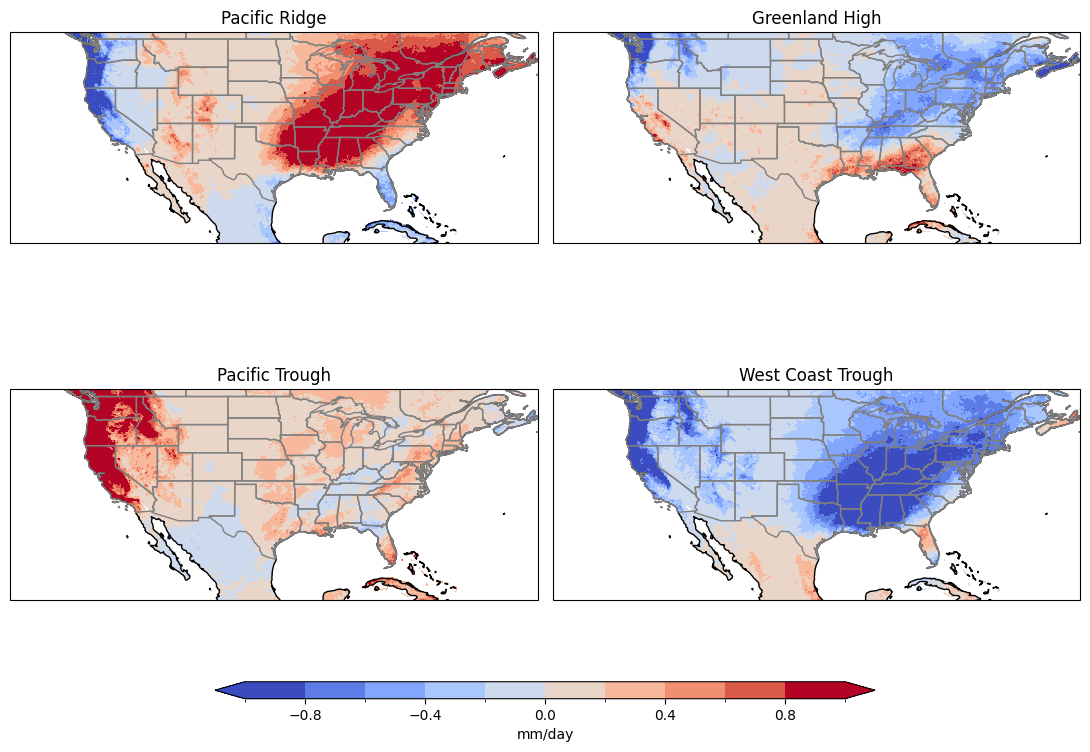

In [2]:
# Load the dataset from the NetCDF file
cluster_pcomp = xr.open_dataset('era5_cluster_comp_p_na_DJF1981-2019.nc')

if 'precip' not in cluster_pcomp:
    raise ValueError("The variable 'precip' does not exist in the dataset. Available variables: ", list(cluster_pcomp.keys()))


nrows = 2
ncols = 2


fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(11.0, 8.5),
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=260)})


axs = axs.flatten()


levs = np.arange(-1, 1.2, 0.2)  


norm = BoundaryNorm(levs, ncolors=256, clip=True)


cmap = plt.get_cmap('coolwarm')  # Replace with 'viridis', 'RdYlBu', or another valid colormap


titles = ['Pacific Ridge', 'Greenland High', 'Pacific Trough', 'West Coast Trough']


for k, ax in enumerate(axs):
    
    precip_data = cluster_pcomp['precip'].isel(cluster=k).load().values  # Load data into memory

   
    if np.isnan(precip_data).all():
        print(f"Cluster {k} - Data is all NaNs. Replacing NaNs with 0 for plotting.")
        precip_data = np.nan_to_num(precip_data, nan=0.0)


    precip_data = np.clip(precip_data, levs.min(), levs.max())

    
    print(f"Cluster {k} - Min: {np.nanmin(precip_data)}, Max: {np.nanmax(precip_data)}")

 
    print(f"Cluster {k} - Data Shape: {precip_data.shape}")

    cs1 = ax.contourf(cluster_pcomp['lon'].values, cluster_pcomp['lat'].values,
                      precip_data, cmap=cmap, extend='both', levels=levs, norm=norm,
                      transform=ccrs.PlateCarree())  # Ensure the transform is set

    ax.set_title(titles[k])

  
    ax.coastlines()


    ax.add_feature(cfeature.STATES, edgecolor='gray')

 
    ax.set_extent([225, 300, 20, 50], crs=ccrs.PlateCarree())

# Add a colorbar below the plots
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(cs1, cax=cbar_ax, orientation='horizontal', label="mm/day")

plt.tight_layout()

plt.savefig('chirps05_cluster_comp_p_na_DJF1981-2019.png')


plt.show()

In [3]:
# Load state shapefile and filter for contiguous US
states = gpd.read_file('cb_2018_us_state_20m.shp')
states = states[~states['NAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

# Define the regimes (clusters) and their names
regimes = {
    0: 'Pacific Ridge',
    1: 'Greenland High',
    2: 'Pacific Trough',
    3: 'West Coast High'
}

# Get the latitude and longitude values from the dataset
lon = cluster_pcomp['lon'].values
lat = cluster_pcomp['lat'].values

# Convert longitude from 0-360 to -180-180
lon = (lon + 180) % 360 - 180

lon_grid, lat_grid = np.meshgrid(lon, lat)


max_valid_lat = 49.975


for cluster, regime_name in regimes.items():
    print(f"\n{regime_name} Precipitation Anomalies by State:")
  
    precip_data = cluster_pcomp['precip'].isel(cluster=cluster).values  # Shape: (lat, lon)
    

    state_precip = {}


    for idx, state in states.iterrows():
        state_name = state['NAME']
        state_geometry = state['geometry']
        
        
        state_geometry = state_geometry.simplify(tolerance=0.01)  
        
        # Bounding box for lat ≤ 49.975°
        valid_lat_box = box(-180, -90, 180, max_valid_lat)
        
        # Clip the state geometry to max at 49.975 degrees to align with precip data
        clipped_geometry = state_geometry.intersection(valid_lat_box)
        
       
        if clipped_geometry.is_empty:
            print(f"{state_name} has no area within the valid latitude range (≤ {max_valid_lat}°). Skipping.")
            continue
        
        # Create a mask 
        state_mask = regionmask.Regions([clipped_geometry]).mask(lon_grid, lat_grid)
        
        # Mask the precipitation data by state
        masked_precip = np.where(state_mask == 0, precip_data, np.nan)  # Apply mask
        
        # Calculate the average precipitation anomaly for each state, filter out nans too
        state_avg_precip = np.nanmean(masked_precip)
        if not np.isnan(state_avg_precip):
            state_precip[state_name] = state_avg_precip
        else:
            print(f"{state_name} has no valid data within the valid latitude range (≤ {max_valid_lat}°).")

 
    for state_name, avg_precip in state_precip.items():
        print(f"{state_name} = {avg_precip:.2f} mm/day")


Pacific Ridge Precipitation Anomalies by State:
Maryland = 0.73 mm/day
Iowa = 0.31 mm/day
Delaware = 0.75 mm/day
Ohio = 1.30 mm/day
Pennsylvania = 1.01 mm/day
Nebraska = 0.06 mm/day
Washington = -0.65 mm/day
Alabama = 0.99 mm/day
Arkansas = 1.57 mm/day
New Mexico = 0.09 mm/day
Texas = 0.15 mm/day
California = -0.77 mm/day
Kentucky = 1.83 mm/day
Georgia = 0.39 mm/day
Wisconsin = 0.41 mm/day
Oregon = -0.70 mm/day
Missouri = 0.96 mm/day
Virginia = 0.59 mm/day
Tennessee = 1.84 mm/day
Louisiana = 0.61 mm/day
New York = 1.00 mm/day
Michigan = 0.73 mm/day
Idaho = -0.00 mm/day
Florida = -0.30 mm/day
Illinois = 1.00 mm/day
Montana = 0.09 mm/day
Minnesota = 0.19 mm/day
Indiana = 1.38 mm/day
Massachusetts = 0.74 mm/day
Kansas = 0.18 mm/day
Nevada = -0.06 mm/day
Vermont = 0.95 mm/day
Connecticut = 0.80 mm/day
New Jersey = 0.79 mm/day
District of Columbia = 0.66 mm/day
North Carolina = 0.34 mm/day
Utah = 0.09 mm/day
North Dakota = 0.04 mm/day
South Carolina = 0.21 mm/day
Mississippi = 1.21 mm/day


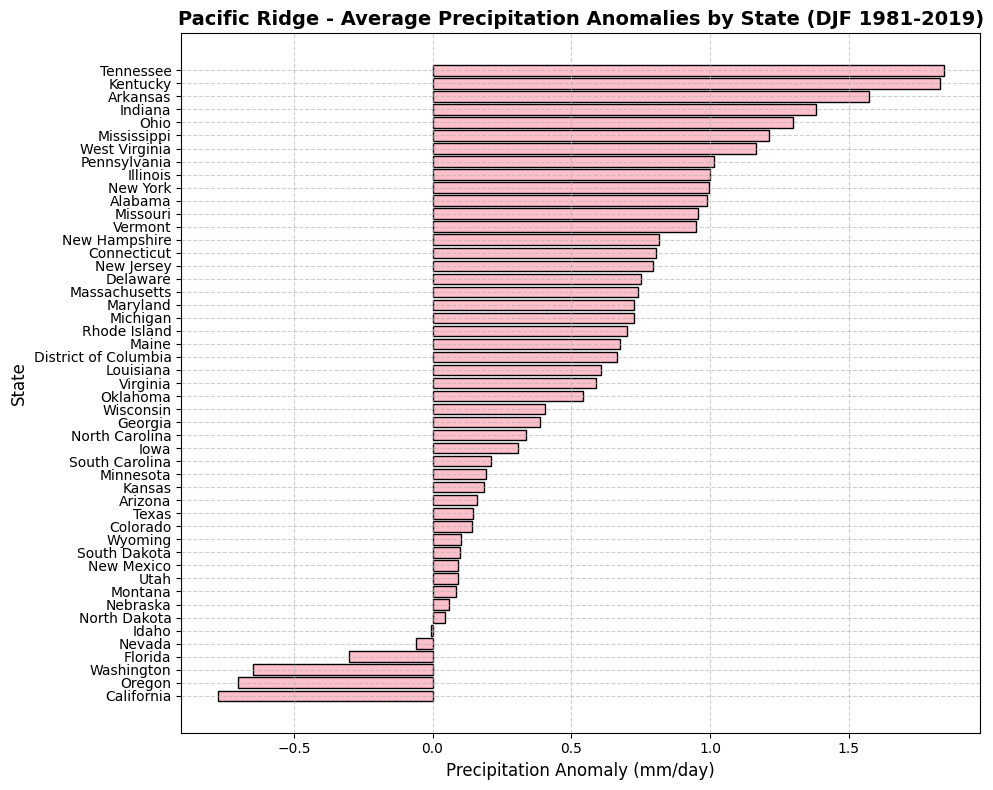

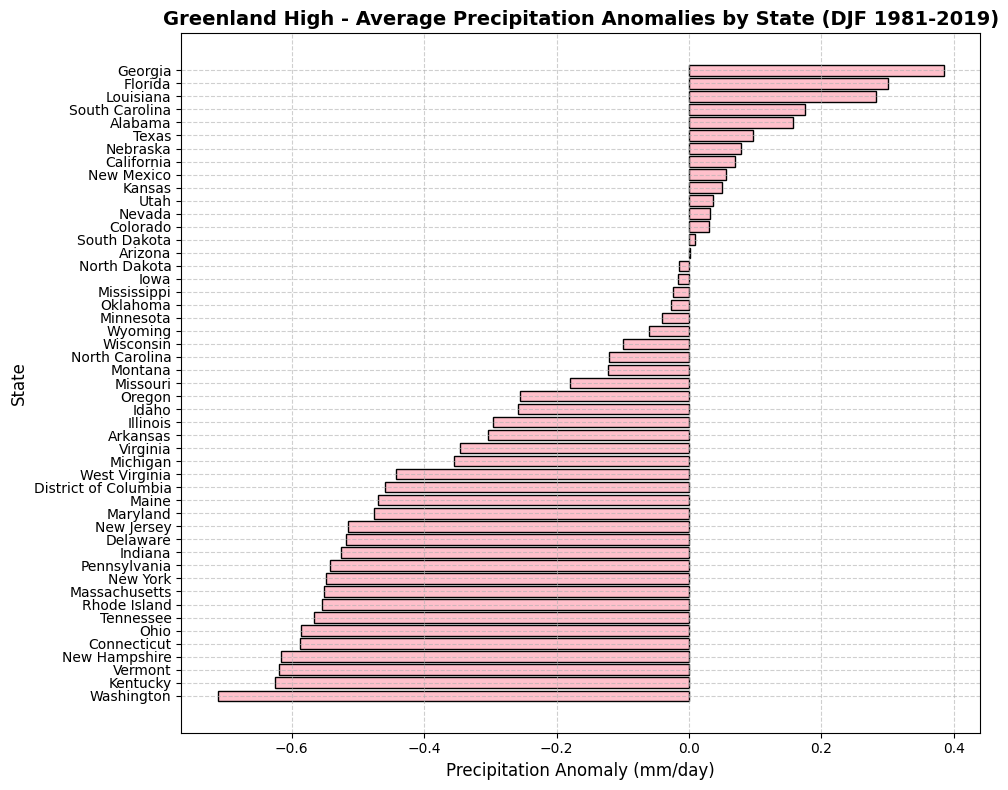

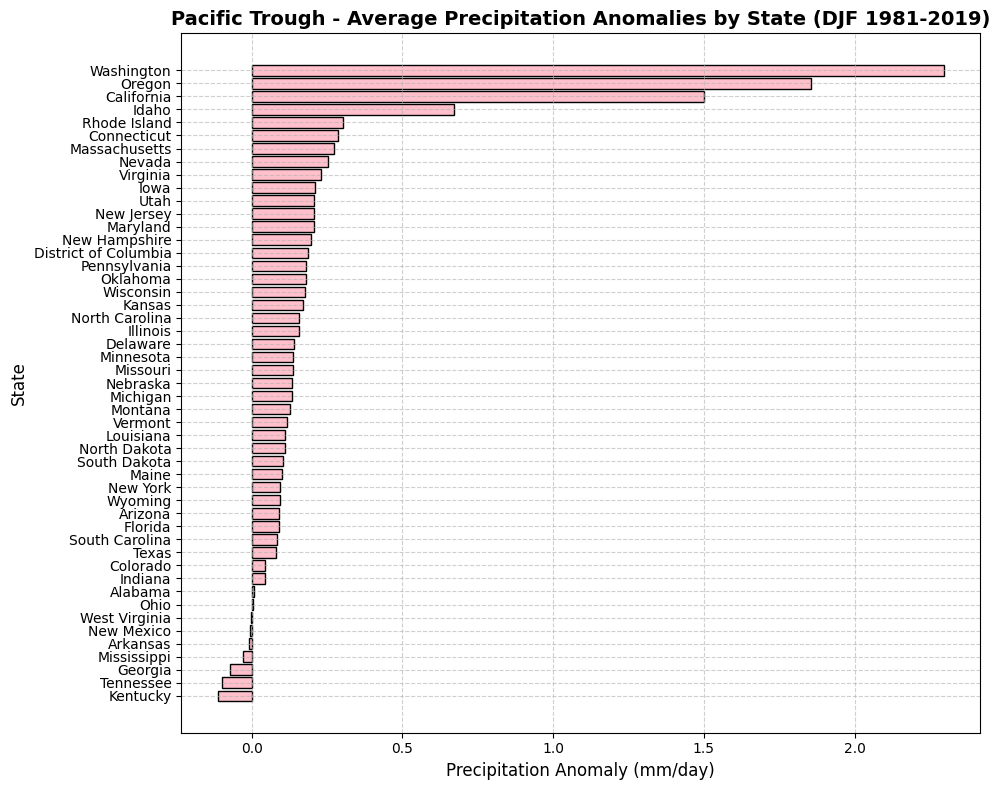

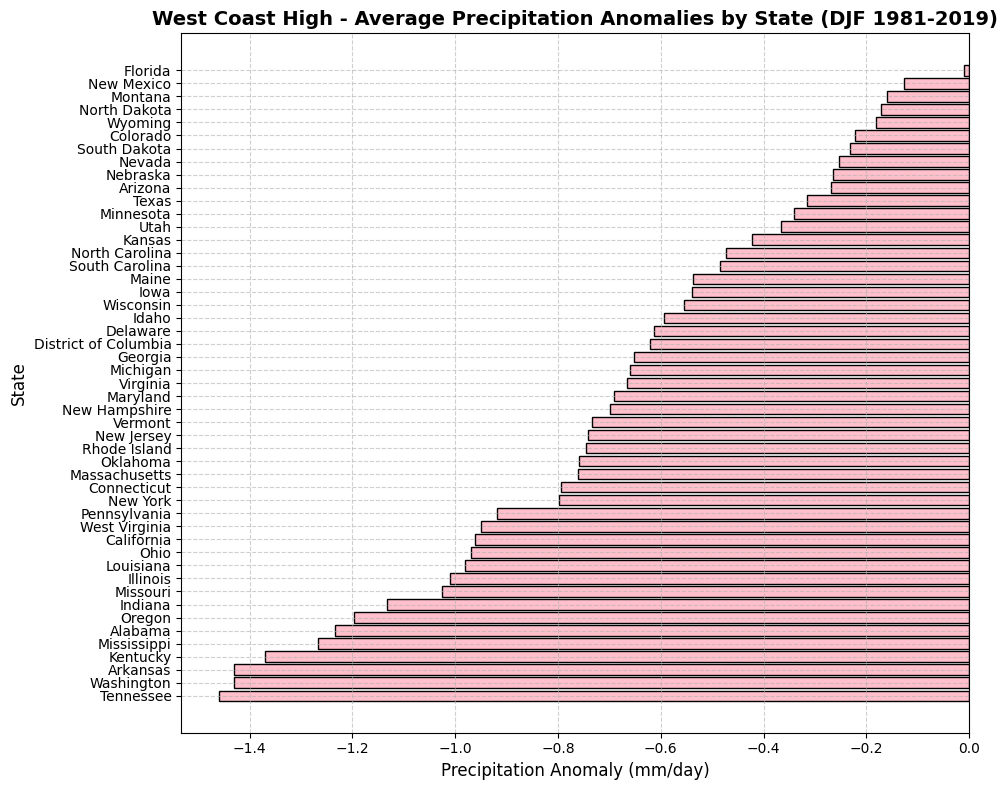

In [4]:

regime_colors = {
    'Pacific Ridge': 'pink',
    'Greenland High': 'pink',
    'Pacific Trough': 'pink',
    'West Coast High': 'pink'  
}

# Loop through each cluster
for cluster, regime_name in regimes.items():
    # Extract precipitation data per regime
    precip_data = cluster_pcomp['precip'].isel(cluster=cluster).values  # Shape: (lat, lon)
    
    
    state_precip = {}

    # Loop through each state to get avg precip anom
    for idx, state in states.iterrows():
        state_name = state['NAME']
        state_geometry = state['geometry']

        state_geometry = state_geometry.simplify(tolerance=0.01)  # Adjust tolerance as needed
        
        
        valid_lat_box = box(-180, -90, 180, max_valid_lat)
        

        clipped_geometry = state_geometry.intersection(valid_lat_box)
        
       
        if clipped_geometry.is_empty:
            print(f"{state_name} has no area within the valid latitude range (≤ {max_valid_lat}°). Skipping.")
            continue
        
        
        state_mask = regionmask.Regions([clipped_geometry]).mask(lon_grid, lat_grid)
        
     
        masked_precip = np.where(state_mask == 0, precip_data, np.nan)  # Apply mask
        
 
        state_avg_precip = np.nanmean(masked_precip)
        
        if not np.isnan(state_avg_precip):
            state_precip[state_name] = state_avg_precip
        else:
            print(f"{state_name} has no valid data within the valid latitude range (≤ {max_valid_lat}°).")

    # Sort states by precipitation anomaly (greatest to smallest)
    sorted_states = sorted(state_precip.items(), key=lambda x: x[1], reverse=True)
    state_names = [x[0] for x in sorted_states]
    precip_values = [x[1] for x in sorted_states]
    
    # Create the bar plot
    plt.figure(figsize=(10, 8))
    plt.barh(state_names, precip_values, color=regime_colors[regime_name], edgecolor='black')
    plt.xlabel('Precipitation Anomaly (mm/day)', fontsize=12)
    plt.ylabel('State', fontsize=12)
    plt.title(f'{regime_name} - Average Precipitation Anomalies by State (DJF 1981-2019)', fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)  # Add gridlines
    plt.gca().invert_yaxis()  # Invert y-axis to show greatest at the top
    plt.tight_layout()
    plt.show()

In [5]:
# Define the state dictionary
state_dictAB = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE',
    11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN',
    19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA',
    26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV',
    33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND', 39: 'OH',
    40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD', 47: 'TN',
    48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI',
    56: 'WY'
}

In [6]:
#Load Crash Data
df = pd.read_csv('DATABASE.csv')
df = df[df['YEAR'] != 2021]
df = df[df['YEAR'] != 2020]
df = df[df['YEAR'] != 1979]
df = df[df['YEAR'] != 1980]
df = df[df['YEAR'] != 1978]
df = df[df['YEAR'] != 1977]
df = df[df['YEAR'] != 1976]
df = df[df['YEAR'] != 1975]
df = df[df['MONTH'].isin([1, 2, 12])]
df

,STATE,COUNTY,CITY,MONTH,DAY,YEAR,HOUR,MINUTE,WEATHER,FATALS,DAY_WEEK,SST_value
28953,1,73,0,1,6,1981,17,30,2,1,3,-0.36
28954,1,3,0,1,15,1981,6,55,5,2,5,-0.36
28955,1,15,100,1,21,1981,19,4,2,1,4,-0.36
28956,1,17,0,1,20,1981,16,30,2,1,3,-0.36
28957,1,77,0,1,20,1981,17,30,2,1,3,-0.36
...,...,...,...,...,...,...,...,...,...,...,...,...
193868,55,81,0,12,30,2019,10,34,4,1,2,0.52
193872,56,21,0,1,11,2019,16,50,4,3,6,0.65
193873,56,5,0,1,23,2019,17,30,4,1,4,0.65
193874,56,41,0,1,24,2019,6,50,11,1,5,0.65


In [7]:
cluster_pcomp

<xarray.Dataset> Size: 28MB
Dimensions:  (cluster: 4, lat: 800, lon: 2200)
Coordinates:
  * lat      (lat) float32 3kB 10.02 10.07 10.12 10.17 ... 49.87 49.92 49.97
  * lon      (lon) float32 9kB 210.0 210.1 210.1 210.2 ... 319.9 319.9 320.0
  * cluster  (cluster) int32 16B 0 1 2 3
Data variables:
    precip   (cluster, lat, lon) float32 28MB ...

In [8]:
fname_precip='/data/esplab/shared/obs/gridded/atm/precip/daily/chirps-v2.0/p05/*'
ds_precip=xr.open_mfdataset(fname_precip,combine='by_coords')
ds_precip = ds_precip.rename({'latitude':'lat','longitude':'lon'})
ds_precip=ds_precip.assign_coords(lon=((ds_precip['lon'] + 360) % 360))
ds_precip=ds_precip.sortby(ds_precip['lon'])
ds_precip


<xarray.Dataset> Size: 905GB
Dimensions:  (time: 15705, lat: 2000, lon: 7200)
Coordinates:
  * lat      (lat) float32 8kB -49.97 -49.92 -49.88 -49.82 ... 49.87 49.92 49.97
  * time     (time) datetime64[ns] 126kB 1981-01-01 1981-01-02 ... 2023-12-31
  * lon      (lon) float32 29kB 0.02499 0.07501 0.125 ... 359.9 359.9 360.0
Data variables:
    precip   (time, lat, lon) float32 905GB dask.array<chunksize=(20, 112, 400), meta=np.ndarray>
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2015-11-20
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/chg/products/CH...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

In [9]:
# Region
min_lat = 10
max_lat = 49.975
#min_lon = 150 #150 E
min_lon = 360-150 #150W
max_lon = 360-40 #40 W
sdate = '1981-01-01'
edate = '2019-12-31'
# Month
seas='DJF'
seas_mon=[1,2,12]

ds_precip_NA=ds_precip.sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon))

In [10]:

# Make Anoms
ds_pclimo=ds_precip_NA.sel(time=slice(sdate,edate)).groupby('time.dayofyear').mean()
ds_panom=ds_precip_NA.groupby('time.dayofyear')-ds_pclimo

# Select the dates
ds_panom=ds_panom.sel(time=slice(sdate,edate))

ds_panom = ds_panom.sel(time=ds_panom['time.month'].isin(seas_mon))

In [11]:
ds_panom

<xarray.Dataset> Size: 25GB
Dimensions:    (lat: 800, time: 3519, lon: 2200)
Coordinates:
  * lat        (lat) float32 3kB 10.02 10.07 10.12 10.17 ... 49.87 49.92 49.97
  * time       (time) datetime64[ns] 28kB 1981-01-01 1981-01-02 ... 2019-12-31
  * lon        (lon) float32 9kB 210.0 210.1 210.1 210.2 ... 319.9 319.9 320.0
    dayofyear  (time) int64 28kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
Data variables:
    precip     (time, lat, lon) float32 25GB dask.array<chunksize=(1, 32, 200), meta=np.ndarray>

In [12]:
# Create a date range 
date_range = pd.date_range(start='1981-01-01', end='2019-12-31', freq='D')

# Extract day of the year for each date 
dayofyear_range = date_range.dayofyear

# Create a mapping from dayofyear to actual dates for each year
dayofyear_to_dates = {}
for year in range(1981, 2020):
    year_dates = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31', freq='D')
    dayofyear_to_dates[year] = {doy: date for doy, date in zip(year_dates.dayofyear, year_dates)}

# Extract cluster assignments and dayofyear from ds_panom
cluster_assignments = ds_panom['cluster'].values  # Shape: (time,)
dayofyear_assignments = ds_panom['dayofyear'].values  # Shape: (time,)

# Map each dayofyear to its corresponding date 
cluster_dates = {cluster: [] for cluster in range(4)}
for idx, (cluster, doy) in enumerate(zip(cluster_assignments, dayofyear_assignments)):
    year = 1981 + (idx // 365)  # Calculate the year based on the index
    if year > 2019:
        continue  
    date = dayofyear_to_dates[year].get(doy)
    if date:
        cluster_dates[cluster].append(date)

# Convert lists of dates to pandas DatetimeIndex
cluster_dates = {cluster: pd.DatetimeIndex(dates) for cluster, dates in cluster_dates.items()}

# Extract year, month, and day from the cluster dates
cluster_year_month_day = {
    cluster: set((date.year, date.month, date.day) for date in dates)
    for cluster, dates in cluster_dates.items()
}

# Filter crash data by year, month, and day, and count fatal crashes for each cluster
cluster_crash_counts = {}
for cluster, year_month_day_set in cluster_year_month_day.items():
    # Filter the crash data to include only the rows where (YEAR, MONTH, DAY) matches the cluster's dates
    # Exclude rows where DAY is 99
    filtered_df = df[
        df.apply(lambda row: (row['YEAR'], row['MONTH'], row['DAY']) in year_month_day_set and row['DAY'] != 99, axis=1)
    ]
    
    # Count the number of crashes
    crash_count = len(filtered_df)
    
    # Store the result inside of a variable
    cluster_crash_counts[cluster] = crash_count

# output
for cluster, crash_count in cluster_crash_counts.items():
    print(f"Cluster {cluster} ({regimes[cluster]}): {crash_count} fatal crashes")

# Print all dates associated with each cluster
for cluster, dates in cluster_dates.items():
    print(f"\nCluster {cluster} ({regimes[cluster]}) Dates:")
    print(dates)

# Verify the total number of crashes
total_crashes = sum(cluster_crash_counts.values())
print(f"\nTotal crashes: {total_crashes}")

KeyError: "No variable named 'cluster'. Variables on the dataset include ['lat', 'time', 'lon', 'dayofyear', 'precip']"

In [ ]:
# state dictionary
state_dictAB = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE',
    11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN',
    19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA',
    26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV',
    33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND', 39: 'OH',
    40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD', 47: 'TN',
    48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI',
    56: 'WY'
}

# Defining the regimes (clusters) and their names
regimes = {
    0: 'Pacific Ridge',
    1: 'Greenland High',
    2: 'Pacific Trough',
    3: 'West Coast High'
}

# list of unique state codes in the crash data
state_codes = df['STATE'].unique()

# Loop through each state code
for state_code in state_codes:
   
    state_abbr = state_dictAB.get(state_code, f'Unknown ({state_code})')
    
    # for the current state
    state_df = df[df['STATE'] == state_code]
    
    # store crash counts for each regime
    state_cluster_crash_counts = {cluster: 0 for cluster in range(4)}
    
    # Count crashes for each regime
    for cluster, year_month_day_set in cluster_year_month_day.items():
        # Filter the crash data to include only the rows where (YEAR, MONTH, DAY) matches the cluster's dates
        # remove day = 99 rows
        filtered_df = state_df[
            state_df.apply(lambda row: (row['YEAR'], row['MONTH'], row['DAY']) in year_month_day_set and row['DAY'] != 99, axis=1)
        ]
        
        # Count the number of crashes
        crash_count = len(filtered_df)
        
        # Store the result
        state_cluster_crash_counts[cluster] = crash_count
    
    # Create a bar plot for the current state
    plt.figure(figsize=(8, 6))
    clusters = list(regimes.keys())
    crash_counts = [state_cluster_crash_counts[cluster] for cluster in clusters]
    regime_names = [regimes[cluster] for cluster in clusters]
    
    plt.bar(regime_names, crash_counts, color='pink', edgecolor='black')
    plt.xlabel('Regime', fontsize=12)
    plt.ylabel('Total Crashes', fontsize=12)
    plt.title(f'Total Crashes by Regime for {state_abbr}', fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)  # Add gridlines
    plt.tight_layout()
   
    plt.savefig(f'{state_abbr}_crashes_by_regime.png', dpi=300)
    
   
    plt.show()